# 1. Bismark QC and methylation values

Читаем `bismark.cov.gz`, фильтруем CpG по coverage, считаем beta-value и M-value

Что находится в `.bismark.cov.gz`

В этом файле одна строка соответствует одному CpG в референсе

Колонки:

```text
chrom  start  end  methylation_percent  methylated_reads  unmethylated_reads
```

Дальше мы посчитаем:

- `coverage` = сколько ридов покрывает CpG
- `beta_value` = доля метилированных ридов, от 0 до 1
- `m_value` = log2-ratio метилированных и неметилированных ридов

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
bismark_file = Path("../data/bismark/MoPh7_1_bismark_bt2_pe.bismark.cov.gz")
bismark_file

PosixPath('../data/bismark/MoPh7_1_bismark_bt2_pe.bismark.cov.gz')

### Читаем таблицу

Файл большой, поэтому для занятия сначала читаем первые 1 000 000 строк. Этого достаточно, чтобы посмотреть формат данных, распределения coverage и метилирования.

Если нужно обработать весь файл, замените `nrows=1_000_000` на `nrows=None`.

In [3]:
columns = [
    "chrom",
    "start",
    "end",
    "meth_percent",
    "meth_count",
    "unmeth_count",
]

nrows = 1_000_000

df = pd.read_csv(
    bismark_file,
    sep="	",
    names=columns,
    compression="gzip",
    nrows=nrows,
)

df

,chrom,start,end,meth_percent,meth_count,unmeth_count
0,chr1,3245,3245,100.0,1,0
1,chr1,3248,3248,100.0,1,0
2,chr1,3254,3254,100.0,1,0
3,chr1,3264,3264,100.0,1,0
4,chr1,3266,3266,100.0,1,0
...,...,...,...,...,...,...
56753432,chrY,62452760,62452760,100.0,1,0
56753433,chrY,62452775,62452775,100.0,1,0
56753434,chrY,62452779,62452779,100.0,1,0
56753435,chrY,62452785,62452785,100.0,1,0


In [4]:
df.shape

(56753437, 6)

### Считаем coverage, beta-value и M-value

`beta_value` лежит от 0 до 1 и показывает долю метилированных ридов

`M-value` — log-ratio methylated/unmethylated reads. Он удобен тем, что лучше раскрывает различия около 0 и 1, где beta-value часто сжимается

In [5]:
df["coverage"] = df["meth_count"] + df["unmeth_count"]
df["beta_value"] = df["meth_count"] / df["coverage"]
df["m_value"] = np.log2((df["meth_count"] + 1) / (df["unmeth_count"] + 1))

df

,chrom,start,end,meth_percent,meth_count,unmeth_count,coverage,beta_value,m_value
0,chr1,3245,3245,100.0,1,0,1,1.0,1.0
1,chr1,3248,3248,100.0,1,0,1,1.0,1.0
2,chr1,3254,3254,100.0,1,0,1,1.0,1.0
3,chr1,3264,3264,100.0,1,0,1,1.0,1.0
4,chr1,3266,3266,100.0,1,0,1,1.0,1.0
...,...,...,...,...,...,...,...,...,...
56753432,chrY,62452760,62452760,100.0,1,0,1,1.0,1.0
56753433,chrY,62452775,62452775,100.0,1,0,1,1.0,1.0
56753434,chrY,62452779,62452779,100.0,1,0,1,1.0,1.0
56753435,chrY,62452785,62452785,100.0,1,0,1,1.0,1.0


In [6]:
df[["meth_percent", "coverage", "beta_value", "m_value"]].describe()

,meth_percent,coverage,beta_value,m_value
count,5.675344e+07,5.675344e+07,5.675344e+07,5.675344e+07
mean,6.241618e+01,1.092257e+01,6.241618e-01,8.041390e-01
std,3.907876e+01,1.436130e+01,3.907876e-01,2.318469e+00
min,0.000000e+00,1.000000e+00,0.000000e+00,-1.235315e+01
25%,2.222222e+01,5.000000e+00,2.222222e-01,-1.000000e+00
50%,8.000000e+01,9.000000e+00,8.000000e-01,1.321928e+00
75%,1.000000e+02,1.500000e+01,1.000000e+00,2.584963e+00
max,1.000000e+02,1.447900e+04,1.000000e+00,7.434628e+00


### Фильтруем CpG по покрытию

CpG с очень низким покрытием ненадежны: одна/две ошибки могут сильно изменить оценку метилирования

CpG с экстремально высоким coverage тоже лучше убрать из учебного анализа, это могут быть повторы или технические артефакты

In [7]:
min_coverage = 5
max_coverage = df["coverage"].quantile(0.99)

filtered = df[
    (df["coverage"] >= min_coverage)
    & (df["coverage"] <= max_coverage)
].copy()

print(f"CpG before filtering: {len(df):,}")
print(f"CpG after filtering:  {len(filtered):,}")
print(f"Max coverage cutoff:  {max_coverage:.0f}")

CpG before filtering: 56,753,437
CpG after filtering:  43,266,954
Max coverage cutoff:  36


### QC-графики

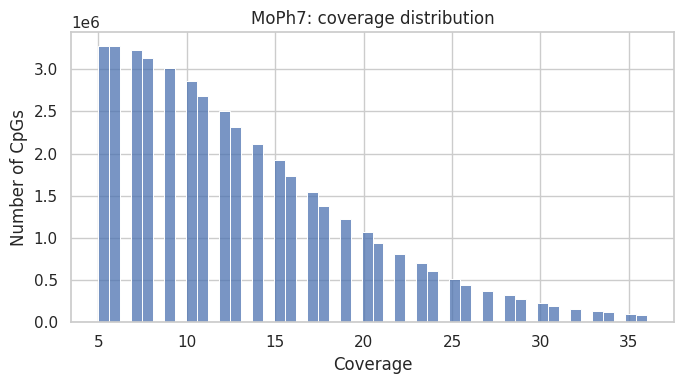

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(filtered["coverage"], bins=50)
plt.xlabel("Coverage")
plt.ylabel("Number of CpGs")
plt.title("MoPh7: coverage distribution")
plt.tight_layout()
plt.show()

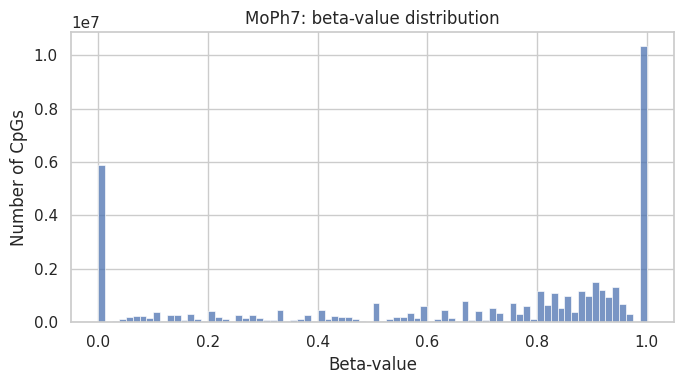

In [9]:
plt.figure(figsize=(7, 4))
sns.histplot(filtered["beta_value"], bins=80)
plt.xlabel("Beta-value")
plt.ylabel("Number of CpGs")
plt.title("MoPh7: beta-value distribution")
plt.tight_layout()
plt.show()

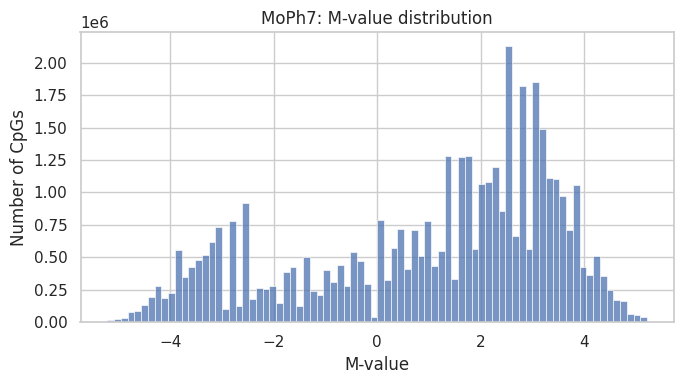

In [10]:
plt.figure(figsize=(7, 4))
sns.histplot(filtered["m_value"], bins=80)
plt.xlabel("M-value")
plt.ylabel("Number of CpGs")
plt.title("MoPh7: M-value distribution")
plt.tight_layout()
plt.show()

## Сохраняем таблицу

Таблицу будем использовать в следующих блокнотах, поэтому нужно пересчитать для всего генома

In [11]:
tables_dir = Path("../results/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

output_table = tables_dir / "MoPh7_cpg_methylation_values.tsv.gz"
filtered.to_csv(output_table, sep="	", index=False, compression="gzip")

output_table

PosixPath('../results/tables/MoPh7_cpg_methylation_values.tsv.gz')

## Вопросы

1. Почему CpG с низким coverage лучше удалить?
2. Чем beta-value отличается от M-value?
3. Почему M-value может быть удобнее для статистического анализа?
4. Что означает пик beta-value около 0 или 1?